In [ ]:
# WEB DEV TEAM PLEASE DELETE BEFORE PUBLISHING - DS TEAM PLEASE KEEP IN THE FINAL VERSION OF THE USE CASE

from IPython.core.display import HTML
HTML("""
<style>
@import url('https://fonts.googleapis.com/css2?family=Poppins:wght@600;700&family=Inter:wght@400;500&display=swap');
body,p,li,div{font-family:'Inter',sans-serif}
body{counter-reset:h2counter}
.usecase-header-bar,.usecase-title,.usecase-section-heading,.usecase-sub-section-heading,.usecase-sub-sub-section-heading,.usecase-unnumbered-heading{font-family:'Poppins',sans-serif}
.usecase-header-bar{padding:16px 20px;background-color:#059669;color:#fff;border-radius:6px 6px 0 0}
.usecase-title{font-size:1.9em;font-weight:800}
.usecase-details{padding-left:20px;padding-bottom:8px;padding-top:8px;font-size:1.1em;color:#121212}
.usecase-section-heading,.usecase-unnumbered-heading{font-weight:700;font-size:1.35em;color:#059669;padding:14px 4px 6px 4px;border-bottom:3px solid #2DBE6C;margin-top:10px}
.usecase-section-heading::before{content:none!important}
.usecase-sub-section-heading{font-weight:600;font-size:1.15em;color:#059669;margin-top:8px}
.usecase-sub-section-heading::before{content:none!important}
.usecase-sub-sub-section-heading{font-weight:500;font-size:1.05em;color:#059669;margin-top:6px}
.usecase-sub-sub-section-heading::before{content:none!important}
.usecase-body{font-size:1em;color:#121212;line-height:1.6;margin-bottom:8px}
.usecase-list{line-height:1.7}
.usecase-list ul,.usecase-list ol{padding-left:24px;margin-top:8px;margin-bottom:12px}
.usecase-list li{margin-bottom:6px}
.usecase-datasets{background-color:rgba(5,150,105,.06);border-left:4px solid #059669;padding:12px 20px;border-radius:0 4px 4px 0;margin-top:12px}
.usecase-datasets ul{margin-top:8px;margin-bottom:8px}
.usecase-contents a,.usecase-datasets a{color:#059669;text-decoration:none}
.usecase-datasets a{font-weight:500}
.usecase-contents a:hover,.usecase-datasets a:hover{text-decoration:underline}
.usecase-contents{line-height:1.9;padding-left:20px}
</style>
""")

<div class="usecase-header-bar"><div class="usecase-title">Pedestrian Activity Near Bus Stops</div></div>

<div class="usecase-details"><b>Authored by: </b>Shilpa Sharma</div>
<div class="usecase-details"><b>Date Created: </b>Trimester 2, 2024</div>
<div class="usecase-details"><b>Time to Complete:</b> 120 mins</div>
<div class="usecase-details"><b>Level: </b>Intermediate</div>
<div class="usecase-details"><b>Pre-requisite Skills: </b>Python, pandas, basic mapping concepts</div>

<div id="scenario" class="usecase-unnumbered-heading"><b>Scenario</b></div>

<div class="usecase-body">
<b>As a</b> transport planner at the City of Melbourne,<br>
<b>I want to</b> know whether the busiest pedestrian locations in the city are actually close to a bus stop,<br>
<b>So that I can</b> spot places where a lot of people walk but bus access is poor, and use that evidence when deciding where new stops should go.
</div>

<div id="what-this-teaches" class="usecase-unnumbered-heading"><b>What this use case will teach you</b></div>

<div class="usecase-body">This use case walks through a complete spatial analysis: pulling two open datasets from an API, cleaning them, joining them by location, and measuring a real relationship between them.</div>

<div class="usecase-list">

- How to download City of Melbourne open data using the Explore API.
- How to safely turn GeoJSON text into usable coordinates.
- How to summarise hundreds of thousands of hourly readings into one row per sensor.
- How to measure the distance from each sensor to its nearest bus stop using a spatial join.
- How to test whether being close to a bus stop is linked to higher foot traffic.
- How to map hundreds of thousands of readings without freezing the browser.

</div>

<div id="background" class="usecase-unnumbered-heading"><b>Background</b></div>

<div class="usecase-body">
Melbourne counts pedestrians automatically using sensors mounted around the city centre. Each sensor reports how many people passed underneath it every hour, which gives a reliable long-run picture of where foot traffic is concentrated.
</div>

<div class="usecase-body">
Bus stops are recorded separately as a list of physical assets, each with its own location. On their own, neither dataset answers a planning question. Put together, they can: if a location has heavy foot traffic but the nearest bus stop is a long walk away, that gap is worth knowing about.
</div>

<div class="usecase-body">
This notebook joins the two datasets on location and checks whether pedestrian volume and bus stop proximity are actually related. Note that this is an observational analysis, so any relationship found shows association, not cause. Busy streets tend to attract both pedestrians and bus stops, so neither one necessarily explains the other.
</div>

<div id="data-sets" class="usecase-unnumbered-heading"><b>Data Sets</b></div>

<div class="usecase-body">
Melbourne has counted pedestrians since 2009, but the API only serves a rolling two-year window. The earlier years are kept in a separate archive that has to be downloaded from the dataset page rather than fetched through the API. Everything below therefore describes recent foot traffic only, not the full history. Section 2 prints the exact dates your run covers.
</div>

<div class="usecase-datasets">

- <a href="https://data.melbourne.vic.gov.au/explore/dataset/pedestrian-counting-system-monthly-counts-per-hour/information/">Pedestrian Counting System &mdash; Monthly (counts per hour)</a> &mdash; one row per sensor per hour, with the count in each direction and the sensor's coordinates.
- <a href="https://data.melbourne.vic.gov.au/explore/dataset/bus-stops/information/">Bus Stops</a> &mdash; one row per bus stop asset, with its location stored as a GeoJSON point.

</div>

<div class="usecase-unnumbered-heading"><b>Contents</b></div>

<div class="usecase-contents">

1. <a href="#section-1">Setting up and loading the data</a><br>
&nbsp;&nbsp;&nbsp;&nbsp;1.1. <a href="#sub-1-1">Importing the libraries</a><br>
&nbsp;&nbsp;&nbsp;&nbsp;1.2. <a href="#sub-1-2">Using the API to call the data from the Melbourne Open Data Site</a><br>
2. <a href="#section-2">Checking data quality</a><br>
3. <a href="#section-3">Preparing the data for analysis</a><br>
&nbsp;&nbsp;&nbsp;&nbsp;3.1. <a href="#sub-3-1">Turning bus stop shapes into coordinates</a><br>
&nbsp;&nbsp;&nbsp;&nbsp;3.2. <a href="#sub-3-2">Turning sensor locations into coordinates</a><br>
&nbsp;&nbsp;&nbsp;&nbsp;3.3. <a href="#sub-3-3">Averaging pedestrian counts per sensor</a><br>
4. <a href="#section-4">Exploring each dataset</a><br>
&nbsp;&nbsp;&nbsp;&nbsp;4.1. <a href="#sub-4-1">How busy are the sensors?</a><br>
&nbsp;&nbsp;&nbsp;&nbsp;4.2. <a href="#sub-4-2">What types of bus stops are there?</a><br>
&nbsp;&nbsp;&nbsp;&nbsp;4.3. <a href="#sub-4-3">How does foot traffic change over the day?</a><br>
5. <a href="#section-5">Measuring how close sensors are to bus stops</a><br>
&nbsp;&nbsp;&nbsp;&nbsp;5.1. <a href="#sub-5-1">Finding the nearest bus stop to each location</a><br>
&nbsp;&nbsp;&nbsp;&nbsp;5.2. <a href="#sub-5-2">Counting bus stops within walking distance</a><br>
&nbsp;&nbsp;&nbsp;&nbsp;5.3. <a href="#sub-5-3">Correlating proximity with pedestrian volume</a><br>
6. <a href="#section-6">Mapping the results</a><br>
&nbsp;&nbsp;&nbsp;&nbsp;6.1. <a href="#sub-6-1">Bus stops and pedestrian activity together</a><br>
&nbsp;&nbsp;&nbsp;&nbsp;6.2. <a href="#sub-6-2">Heat map of pedestrian activity</a>

</div>

<div id="section-1" class="usecase-section-heading"><b>1. Setting up and loading the data</b></div>

<div class="usecase-body">We import the libraries, then download both datasets straight from the API.</div>

<div id="sub-1-1" class="usecase-sub-section-heading"><b>1.1. Importing the libraries</b></div>

<div class="usecase-body">Each library has one job here: pandas for tables, GeoPandas for anything involving location, folium for the interactive map, and matplotlib and seaborn for the charts.</div>

In [2]:
import json                      # parsing the GeoJSON text in the bus stop data
from io import StringIO           # lets pandas read the API response as if it were a file

import pandas as pd               # tables
import geopandas as gpd           # tables that understand location
import matplotlib.pyplot as plt   # charts
import seaborn as sns             # nicer looking charts
import requests                   # calling the API
import folium                     # interactive map
from folium.plugins import HeatMap

# The colour order used throughout this notebook, taken from the MOP style guide.
GREEN, PURPLE, ORANGE, BLUE, YELLOW = "#059669", "#9333EA", "#F97316", "#2563EB", "#EAB308"

# A Coordinate Reference System (CRS) is the system used to say where
# something is on Earth. EPSG numbers are the catalogue codes for those
# systems. We need two of them; section 5 explains why, but in short you
# cannot measure a distance in degrees.
CRS_DEGREES = "EPSG:4326"   # latitude and longitude, as the API supplies them
CRS_METRES = "EPSG:7855"    # Melbourne's local grid, measured in metres

sns.set_style("whitegrid")

<div id="sub-1-2" class="usecase-sub-section-heading"><b>1.2. Using the API to call the data from the Melbourne Open Data Site</b></div>

<div class="usecase-body">One small function handles both downloads. It asks the API for the whole dataset as CSV and hands back a DataFrame.</div>

In [3]:
def fetch_melbourne_dataset(dataset_id):
    """Download a full City of Melbourne dataset and return it as a DataFrame.

    dataset_id is the name shown in the dataset's URL, for example 'bus-stops'.
    """
    base_url = "https://data.melbourne.vic.gov.au/api/explore/v2.1/catalog/datasets/"
    export_url = f"{base_url}{dataset_id}/exports/csv"

    params = {
        "select": "*",
        "limit": -1,        # -1 means every record, not just the first page
        "lang": "en",
        "timezone": "UTC",
    }

    response = requests.get(export_url, params=params, timeout=180)
    response.raise_for_status()   # stop immediately with a clear error if the call failed

    # The export endpoint returns semicolon-separated CSV.
    return pd.read_csv(StringIO(response.content.decode("utf-8")), delimiter=";")

<div class="usecase-body">Now we load both datasets. The pedestrian file is large, so this cell can take a minute or two.</div>

In [4]:
bus_stops = fetch_melbourne_dataset("bus-stops")
pedestrians = fetch_melbourne_dataset("pedestrian-counting-system-monthly-counts-per-hour")

print(f"Bus stops:            {len(bus_stops):,} rows x {bus_stops.shape[1]} columns")
print(f"Pedestrian readings:  {len(pedestrians):,} rows x {pedestrians.shape[1]} columns")

Bus stops:            309 rows x 16 columns
Pedestrian readings:  1,613,233 rows x 9 columns


<div class="usecase-body">
<b>What this shows:</b> the size of each dataset. There are a few hundred bus stops but hundreds of thousands of pedestrian readings, because every sensor reports once an hour.
</div>

<div class="usecase-body">
<b>Why it matters:</b> the size gap decides how we work. The two tables cannot be joined row to row. The pedestrian data has to be summarised down to one row per sensor first, which is what section 3 does.
</div>

<div id="section-2" class="usecase-section-heading"><b>2. Checking data quality</b></div>

<div class="usecase-body">Before analysing anything we check what each table contains and whether values are missing.</div>

In [5]:
print("=== BUS STOPS ===")
bus_stops.info()

print("\n=== MISSING VALUES (bus stops) ===")
missing_stops = bus_stops.isna().sum()
print(missing_stops[missing_stops > 0] if missing_stops.any() else "None")

print("\n=== PEDESTRIAN COUNTS ===")
pedestrians.info()

print("\n=== MISSING VALUES (pedestrian counts) ===")
missing_ped = pedestrians.isna().sum()
print(missing_ped[missing_ped > 0] if missing_ped.any() else "None")

# A sensor NAME is not the same thing as a sensor LOCATION. Some names are
# reused at two positions, and some positions have no name recorded at all,
# so these counts deliberately disagree.
named = pedestrians.dropna(subset=["sensor_name"])
print(f"\nDistinct sensor names             : {pedestrians['sensor_name'].nunique()}")
print(f"Distinct location ids             : {pedestrians['location_id'].nunique()}")
print(f"Distinct name + location pairs    : {len(named.groupby(['sensor_name', 'location_id']))}")
print(f"Rows with no sensor name recorded : {pedestrians['sensor_name'].isna().sum():,}")

print(f"\nDate range: {pedestrians['sensing_date'].min()} to {pedestrians['sensing_date'].max()}")

=== BUS STOPS ===
<class 'pandas.DataFrame'>
RangeIndex: 309 entries, 0 to 308
Data columns (total 16 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   geo_point_2d  309 non-null    str    
 1   geo_shape     309 non-null    str    
 2   prop_id       309 non-null    int64  
 3   addresspt1    309 non-null    float64
 4   addressp_1    309 non-null    int64  
 5   asset_clas    309 non-null    str    
 6   asset_type    309 non-null    str    
 7   objectid      309 non-null    int64  
 8   str_id        309 non-null    int64  
 9   addresspt     309 non-null    int64  
 10  asset_subt    0 non-null      float64
 11  model_desc    309 non-null    str    
 12  mcc_id        309 non-null    int64  
 13  roadseg_id    309 non-null    int64  
 14  descriptio    309 non-null    str    
 15  model_no      309 non-null    str    
dtypes: float64(2), int64(7), str(7)
memory usage: 38.8 KB

=== MISSING VALUES (bus stops) ===
asset_subt    309
d

sensor_name    25593
location       25593
dtype: int64

Distinct sensor names             : 97
Distinct location ids             : 103


Distinct name + location pairs    : 100
Rows with no sensor name recorded : 25,593

Date range: 2024-08-04 to 2026-08-03


<div class="usecase-body">
<b>What this shows:</b> the column names and types in both tables, any columns with missing values, how many distinct sensors exist, and the period the readings cover.
</div>

<div class="usecase-body">
<b>Why it matters:</b> it confirms the columns we rely on exist and are populated, and it settles what a "sensor" actually means here. The counts differ on purpose, for two reasons:
</div>

<div class="usecase-list">

- A few <b>names are reused at two different positions</b> &mdash; a sensor that was relocated, or two units on the same bridge.
- A few <b>location ids never have a name recorded</b>, so they cannot be identified and are excluded.

</div>

<div class="usecase-body">
The figure that matters from here on is the <b>name + location pairs</b>, because a spatial join works on positions, not labels: two sensors sharing a name still sit in different streets and must be measured separately. So the rest of the notebook counts sensor <i>locations</i>, and that number is legitimately higher than the number of distinct names. The date range should span about two years, for the reason given in the Data Sets section above.
</div>

<div class="usecase-body">Any column that is completely empty carries no information, so we drop it. Doing this in code rather than describing it in text means the notebook actually performs the step when it runs.</div>

In [6]:
# Drop columns where every value is missing. Nothing is lost, and it keeps
# the later summaries readable.
empty_columns = [c for c in bus_stops.columns if bus_stops[c].isna().all()]

if empty_columns:
    bus_stops = bus_stops.drop(columns=empty_columns)
    print(f"Dropped empty columns: {empty_columns}")
else:
    print("No completely empty columns found.")

print(f"Bus stops now has {bus_stops.shape[1]} columns.")

Dropped empty columns: ['asset_subt']
Bus stops now has 15 columns.


<div class="usecase-body">
<b>What this shows:</b> which columns were removed, if any, and how many remain.
</div>

<div class="usecase-body">
<b>Why it matters:</b> the source data changes over time, so rather than hardcoding a column name that may not exist on a future run, the check is written to adapt.
</div>

<div id="section-3" class="usecase-section-heading"><b>3. Preparing the data for analysis</b></div>

<div class="usecase-body">Both datasets store location as text, so we convert them into real coordinates and then reduce the pedestrian readings to one row per sensor.</div>

<div id="sub-3-1" class="usecase-sub-section-heading"><b>3.1. Turning bus stop shapes into coordinates</b></div>

<div class="usecase-body">The bus stop location arrives as a GeoJSON string such as <code>{"type": "Point", "coordinates": [144.96, -37.81]}</code>. We read it with <code>json.loads</code>, which only accepts valid JSON. Using Python's <code>eval</code> here would run whatever the text contained, which is unsafe with data fetched over a network.</div>

In [7]:
def point_from_geojson(geo_shape):
    """Return (longitude, latitude) from a GeoJSON point string, or (None, None)."""
    if pd.isna(geo_shape):
        return (None, None)

    shape = json.loads(geo_shape)          # safe: rejects anything that is not valid JSON
    longitude, latitude = shape["coordinates"]
    return (longitude, latitude)


# Apply to every row, then split the pairs into two columns.
coordinates = bus_stops["geo_shape"].apply(point_from_geojson)
bus_stops["Longitude"] = [lon for lon, lat in coordinates]
bus_stops["Latitude"] = [lat for lon, lat in coordinates]

# Drop any stop we could not place on the map.
bus_stops = bus_stops.dropna(subset=["Longitude", "Latitude"])

# Turn the table into a GeoDataFrame so GeoPandas can measure distances with it.
bus_stops_geo = gpd.GeoDataFrame(
    bus_stops,
    geometry=gpd.points_from_xy(bus_stops["Longitude"], bus_stops["Latitude"]),
    crs=CRS_DEGREES,
)

print(f"{len(bus_stops_geo)} bus stops with valid coordinates.")
bus_stops_geo[["descriptio", "asset_type", "Longitude", "Latitude"]].head()

309 bus stops with valid coordinates.


,descriptio,asset_type,Longitude,Latitude
0,Sign - Public Transport 1 Panel Bus Stop Type 1,Sign - Public Transport,144.960979,-37.800007
1,Sign - Public Transport 1 Panel Bus Stop Type 11,Sign - Public Transport,144.916638,-37.807816
2,Sign - Public Transport 1 Panel Bus Stop Type 8,Sign - Public Transport,144.956949,-37.825002
3,Sign - Public Transport 1 Panel Bus Stop Type 12,Sign - Public Transport,144.948458,-37.798593
4,Sign - Public Transport 1 Panel Bus Stop Type 1,Sign - Public Transport,144.964491,-37.800562


<div class="usecase-body">
<b>What this shows:</b> the first few bus stops with their description, type and extracted coordinates.
</div>

<div class="usecase-body">
<b>Why it matters:</b> it confirms the GeoJSON was parsed correctly. Melbourne longitudes should sit near 144.9 and latitudes near -37.8. Values far from that would mean longitude and latitude were swapped, which is easy to do and would silently ruin every distance later.
</div>

<div id="sub-3-2" class="usecase-sub-section-heading"><b>3.2. Turning sensor locations into coordinates</b></div>

<div class="usecase-body">The pedestrian data stores location as a single <code>"latitude, longitude"</code> string, so we split it into two numeric columns.</div>

In [8]:
# Split "-37.8, 144.9" into two numeric columns.
latlon = pedestrians["location"].str.split(",", expand=True)
pedestrians["Latitude"] = pd.to_numeric(latlon[0], errors="coerce")
pedestrians["Longitude"] = pd.to_numeric(latlon[1], errors="coerce")

# The API supplies the date and the hour in two separate columns, so we combine
# them into one timestamp and keep the hour on its own for the daily pattern.
pedestrians["hourday"] = pd.to_numeric(pedestrians["hourday"], errors="coerce")
pedestrians["reading_time"] = (
    pd.to_datetime(pedestrians["sensing_date"], errors="coerce")
    + pd.to_timedelta(pedestrians["hourday"], unit="h")
)
pedestrians["HourOfDay"] = pedestrians["hourday"]

# Keep only rows we can place on a map and time correctly.
before = len(pedestrians)
pedestrians = pedestrians.dropna(subset=["Latitude", "Longitude", "reading_time"])
print(f"Dropped {before - len(pedestrians):,} rows with an unusable location or timestamp.")
print(f"{len(pedestrians):,} readings remain.")

Dropped 25,593 rows with an unusable location or timestamp.
1,587,640 readings remain.


<div class="usecase-body">
<b>What this shows:</b> how many readings had to be discarded and how many are left.
</div>

<div class="usecase-body">
<b>Why it matters:</b> a row without a usable location cannot take part in a spatial join. Reporting the number dropped keeps the cleaning honest, rather than losing rows silently.
</div>

<div id="sub-3-3" class="usecase-sub-section-heading"><b>3.3. Averaging pedestrian counts per sensor</b></div>

<div class="usecase-body">Each sensor appears thousands of times, once per hour. We collapse that into a single row per sensor holding its average hourly count, which is the figure used for the rest of the analysis.</div>

In [9]:
# One row per sensor LOCATION. We group on name and id together because a
# name on its own is not unique (see section 2).
sensor_activity = (
    pedestrians
    .groupby(["sensor_name", "location_id"], as_index=False)
    .agg(
        Latitude=("Latitude", "first"),
        Longitude=("Longitude", "first"),
        avg_hourly_count=("pedestriancount", "mean"),
        busiest_hour_count=("pedestriancount", "max"),
        hours_recorded=("pedestriancount", "size"),
    )
)

# Same treatment as the bus stops: make it a GeoDataFrame.
sensors_geo = gpd.GeoDataFrame(
    sensor_activity,
    geometry=gpd.points_from_xy(sensor_activity["Longitude"], sensor_activity["Latitude"]),
    crs=CRS_DEGREES,
)

print(f"{len(sensors_geo)} sensor locations summarised from {len(pedestrians):,} hourly readings.")
sensors_geo[["sensor_name", "avg_hourly_count", "busiest_hour_count", "hours_recorded"]] \
    .sort_values("avg_hourly_count", ascending=False).head(10)

100 sensor locations summarised from 1,587,640 hourly readings.


,sensor_name,avg_hourly_count,busiest_hour_count,hours_recorded
87,Swa123_T,1514.582214,6217,17418
90,Swa31,1468.694170,5411,17392
78,SouthB_T,1328.247800,9836,17498
71,QVN_T,1219.292462,5087,17445
27,ElFi_T,1205.883706,6528,17473
89,Swa295_T,1128.702195,4894,17498
69,PriNW_T,1091.833295,7381,17486
14,Bou292_T,1009.210027,4620,11689
32,Eli368_T,1003.246350,3202,11849
28,Eli124_T,932.914734,3848,9617


<div class="usecase-body">
<b>What this shows:</b> the ten busiest sensors by average hourly pedestrian count, alongside their peak hour and how many hours of data each contributed.
</div>

<div class="usecase-body">
<b>Why it matters:</b> this is the table the whole analysis rests on. There is one row per sensor location, which is why the count here is slightly higher than the number of distinct sensor names reported in section 2. Using an average rather than a total matters, because sensors installed recently have fewer recorded hours and their totals would look artificially low. The <code>hours_recorded</code> column makes that difference visible.
</div>

<div id="section-4" class="usecase-section-heading"><b>4. Exploring each dataset</b></div>

<div class="usecase-body">A quick look at each dataset on its own, before combining them.</div>

<div id="sub-4-1" class="usecase-sub-section-heading"><b>4.1. How busy are the sensors?</b></div>

<div class="usecase-body">The spread of average hourly counts across sensors.</div>

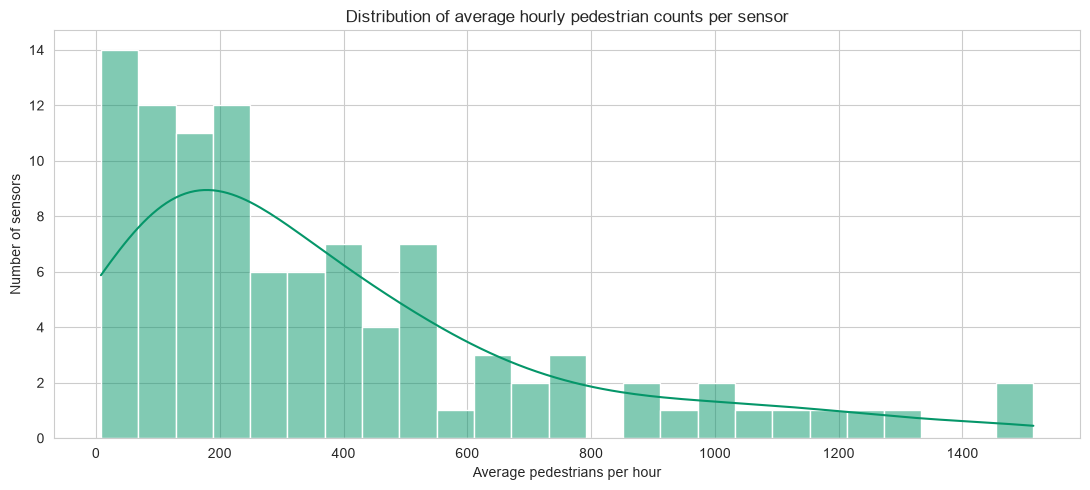

In [10]:
plt.figure(figsize=(11, 5))
sns.histplot(sensors_geo["avg_hourly_count"], bins=25, kde=True, color=GREEN)
plt.title("Distribution of average hourly pedestrian counts per sensor")
plt.xlabel("Average pedestrians per hour")
plt.ylabel("Number of sensors")
plt.tight_layout()
plt.show()

<div class="usecase-body">
<b>What this shows:</b> how many sensors fall into each range of average hourly foot traffic.
</div>

<div class="usecase-body">
<b>Why it matters:</b> the distribution is right-skewed, meaning most sensors record modest numbers while a few very busy ones sit far to the right. That shape is the reason we use Spearman rather than Pearson correlation in section 5, since Spearman ranks the values instead of assuming a straight-line relationship.
</div>

<div id="sub-4-2" class="usecase-sub-section-heading"><b>4.2. What types of bus stops are there?</b></div>

<div class="usecase-body">The bus stop dataset records an asset type for each stop.</div>

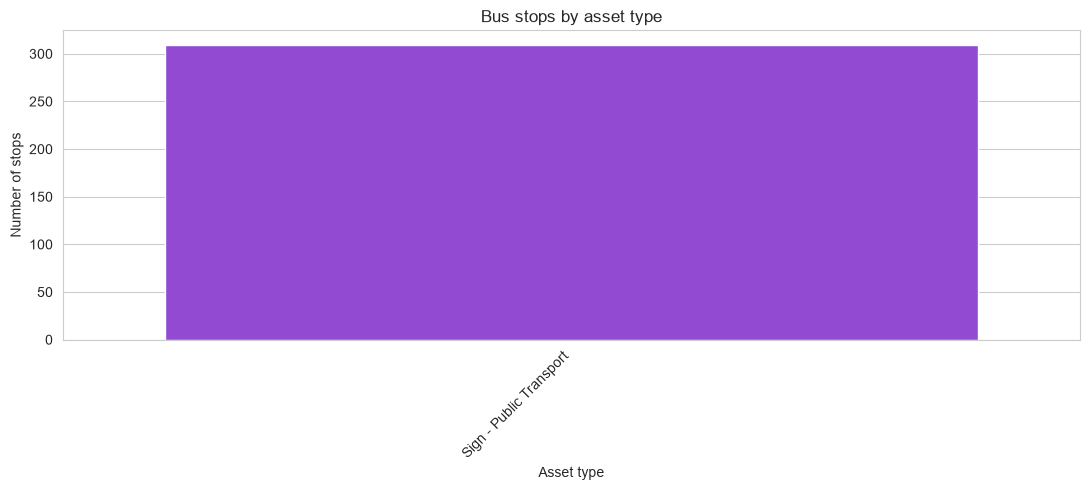

In [11]:
plt.figure(figsize=(11, 5))
order = bus_stops_geo["asset_type"].value_counts().index
sns.countplot(data=bus_stops_geo, x="asset_type", order=order, color=PURPLE)
plt.title("Bus stops by asset type")
plt.xlabel("Asset type")
plt.ylabel("Number of stops")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

<div class="usecase-body">
<b>What this shows:</b> how many bus stops exist of each recorded asset type, most common first.
</div>

<div class="usecase-body">
<b>Why it matters:</b> it confirms we are counting bus stops and not a mixture of unrelated street assets, which would distort every distance we calculate.
</div>

<div id="sub-4-3" class="usecase-sub-section-heading"><b>4.3. How does foot traffic change over the day?</b></div>

<div class="usecase-body">Averaging every reading by hour of day shows the daily rhythm. We plot the averaged values rather than every individual reading, which would be unreadable and slow.</div>

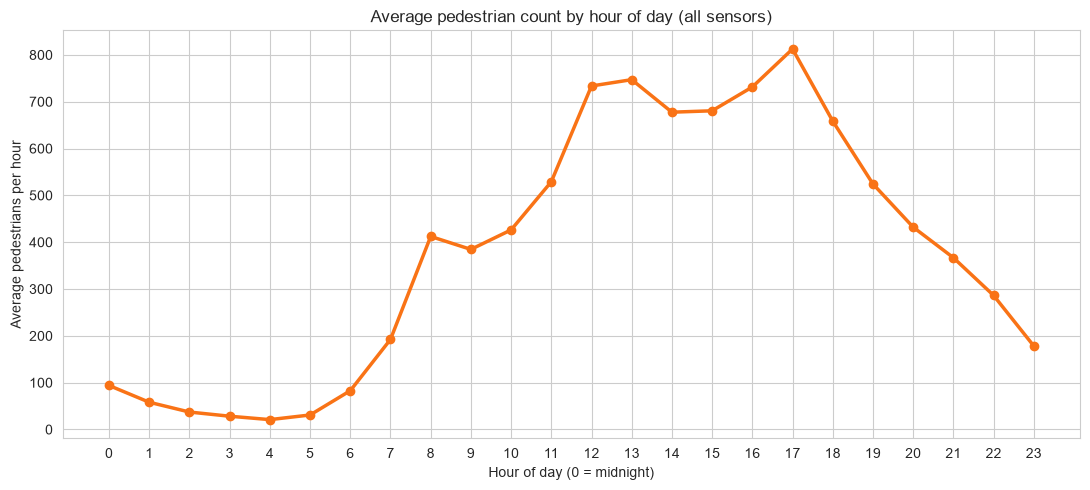

In [12]:
hourly_pattern = pedestrians.groupby("HourOfDay")["pedestriancount"].mean()

plt.figure(figsize=(11, 5))
plt.plot(hourly_pattern.index, hourly_pattern.values,
         color=ORANGE, linewidth=2.5, marker="o")
plt.title("Average pedestrian count by hour of day (all sensors)")
plt.xlabel("Hour of day (0 = midnight)")
plt.ylabel("Average pedestrians per hour")
plt.xticks(range(0, 24))
plt.tight_layout()
plt.show()

<div class="usecase-body">
<b>What this shows:</b> the average number of pedestrians recorded in each hour of the day, combined across all sensors.
</div>

<div class="usecase-body">
<b>Why it matters:</b> the shape of this curve tells us what kind of city centre we are looking at. Peaks around the morning and evening commute point to work travel, while a broad afternoon plateau suggests shopping and leisure. This is also the pattern bus timetables need to match.
</div>

<div id="section-5" class="usecase-section-heading"><b>5. Measuring how close sensors are to bus stops</b></div>

<div class="usecase-body">
This is the part that answers the actual question. Plotting both datasets on one map only shows that they overlap; it does not measure anything. Here we calculate, for every sensor, how far away the nearest bus stop is and how many stops sit within walking distance, then test whether those numbers relate to how busy the sensor is.
</div>

<div id="sub-5-1" class="usecase-sub-section-heading"><b>5.1. Finding the nearest bus stop to each location</b></div>

<div class="usecase-body">
Latitude and longitude are angles, not distances. Near Melbourne one degree of latitude is about 111 km but one degree of longitude is only about 88 km, so subtracting two pairs of coordinates does not give a usable distance.
</div>

<div class="usecase-body">
We therefore convert both layers to a grid measured in metres first. EPSG codes simply identify coordinate systems: <b>EPSG:4326</b> is latitude and longitude, and <b>EPSG:7855</b> is Melbourne's local metre grid. A nearest-neighbour spatial join then pairs each sensor location with its closest bus stop.
</div>

In [13]:
# Convert both layers from degrees to metres before measuring anything.
sensors_m = sensors_geo.to_crs(CRS_METRES)
stops_m = bus_stops_geo.to_crs(CRS_METRES)

# For each sensor, find the single closest bus stop and record the distance.
nearest = gpd.sjoin_nearest(
    sensors_m,
    stops_m[["descriptio", "geometry"]],
    how="left",
    distance_col="distance_to_nearest_stop_m",
).drop(columns="index_right")

# sjoin_nearest emits one row per tie when two stops are equally close.
# De-duplicate on the index so each sensor keeps exactly one row, without
# merging sensors that share a name but sit at different locations.
nearest = nearest[~nearest.index.duplicated(keep="first")]

distances = nearest["distance_to_nearest_stop_m"]
print("Distance from each sensor location to its nearest bus stop")
print(f"  closest  : {distances.min():>4.0f} m")
print(f"  typical  : {distances.median():>4.0f} m")
print(f"  furthest : {distances.max():>4.0f} m")

Distance from each sensor location to its nearest bus stop
  closest  :   17 m
  typical  :  189 m
  furthest :  843 m


<div class="usecase-body">
<b>What this shows:</b> the closest, typical and furthest distance from a sensor location to its nearest bus stop.
</div>

<div class="usecase-body">
<b>Why it matters:</b> this is the first genuine link between the two datasets. The median tells us how well served a typical pedestrian location is, and the maximum flags the most isolated one. As a rule of thumb, planners treat about 400 m, roughly a five minute walk, as comfortable access.
</div>

<div id="sub-5-2" class="usecase-sub-section-heading"><b>5.2. Counting bus stops within walking distance</b></div>

<div class="usecase-body">Distance to the single nearest stop ignores how well served a location is overall, so we also count how many stops lie within 400 metres.</div>

In [14]:
WALKING_DISTANCE_M = 400   # about a five minute walk

# For each sensor, count how many bus stops fall inside the walking radius.
nearest["stops_within_400m"] = [
    int(stops_m.distance(point).le(WALKING_DISTANCE_M).sum())
    for point in nearest.geometry
]

# Group the locations by how far their nearest stop is, so both measures
# can be read together.
distance_band = pd.cut(
    nearest["distance_to_nearest_stop_m"],
    bins=[0, 100, 200, 300, WALKING_DISTANCE_M, float("inf")],
    labels=["under 100 m", "100-200 m", "200-300 m", "300-400 m", "over 400 m"],
)

summary = pd.DataFrame({
    "locations": distance_band.value_counts().sort_index(),
    "avg stops within 400 m": nearest.groupby(distance_band, observed=False)["stops_within_400m"].mean().round(1),
})
summary.index.name = "distance to nearest stop"
print(summary.to_string())

no_stop_nearby = (nearest["stops_within_400m"] == 0).sum()
print()
print(f"{no_stop_nearby} locations have no bus stop within {WALKING_DISTANCE_M} m.")

# Silent guard. Beyond the threshold, the count inside it must be zero.
# If this ever fails, the two layers are in different coordinate systems.
assert (nearest["distance_to_nearest_stop_m"] > WALKING_DISTANCE_M).sum() == no_stop_nearby

                          locations  avg stops within 400 m
distance to nearest stop                                   
under 100 m                      31                    11.3
100-200 m                        20                     9.7
200-300 m                        23                     6.6
300-400 m                         7                     2.6
over 400 m                       19                     0.0

19 locations have no bus stop within 400 m.


<div class="usecase-body">
<b>What this shows:</b> how many bus stops are within a five minute walk, grouped by how far away the nearest one is.
</div>

<div class="usecase-body">
<b>Why it matters:</b> counting stops measures access better than distance alone, because a location with six stops nearby is served very differently from one with a single stop the same distance away. The locations with none are the candidates for review. The two measures are different views of the same geometry, which is why the count reaches zero exactly where the distance passes 400 m.
</div>

<div id="sub-5-3" class="usecase-sub-section-heading"><b>5.3. Correlating proximity with pedestrian volume</b></div>

<div class="usecase-body">Now we can test the relationship directly. We correlate only measures that carry real meaning. Correlating identifier columns such as <code>prop_id</code> or <code>objectid</code> would produce a neat looking heatmap with no interpretable content, because those numbers are labels rather than quantities.</div>

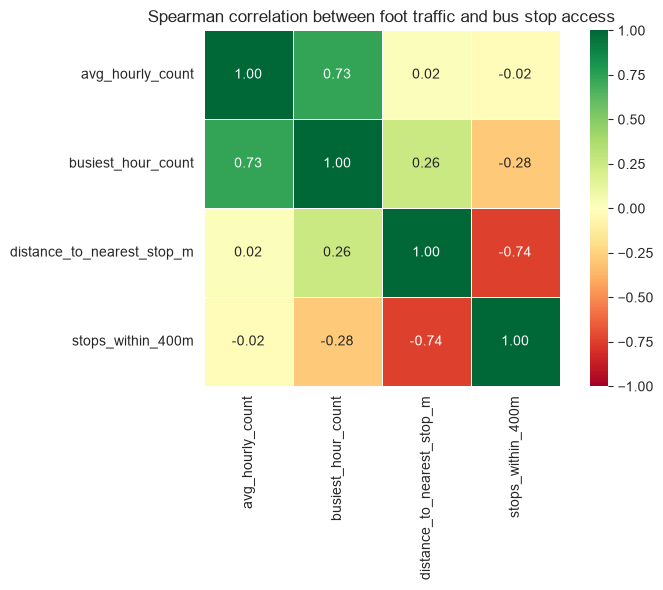

Foot traffic vs distance to nearest stop: 0.02
Foot traffic vs number of stops within 400 m: -0.02


In [15]:
# Only genuine measurements go into the correlation, never ID columns.
analysis_columns = [
    "avg_hourly_count",             # how busy the sensor is
    "busiest_hour_count",           # its peak hour
    "distance_to_nearest_stop_m",   # how far the closest bus stop is
    "stops_within_400m",            # how many stops are within a short walk
]

# Spearman ranks the values, so a few very busy sensors cannot dominate the result.
correlation = nearest[analysis_columns].corr(method="spearman")

plt.figure(figsize=(8, 6))
sns.heatmap(correlation, annot=True, fmt=".2f", cmap="RdYlGn",
            vmin=-1, vmax=1, square=True, linewidths=0.5)
plt.title("Spearman correlation between foot traffic and bus stop access")
plt.tight_layout()
plt.show()

print(
    "Foot traffic vs distance to nearest stop: "
    f"{correlation.loc['avg_hourly_count', 'distance_to_nearest_stop_m']:.2f}"
)
print(
    "Foot traffic vs number of stops within 400 m: "
    f"{correlation.loc['avg_hourly_count', 'stops_within_400m']:.2f}"
)

<div class="usecase-body">
<b>What this shows:</b> how strongly each pair of measures moves together, from -1 (opposite directions) through 0 (unrelated) to +1 (same direction).
</div>

<div class="usecase-body">
<b>Why it matters:</b> these two numbers are the answer to the scenario. A negative value for distance would mean busier locations tend to have a bus stop closer by, and a positive value for the count would mean busier locations have more stops nearby. Both would be expected if stops were placed where demand is.
</div>

<div class="usecase-body">
<b>What we actually found:</b> both correlations sit close to zero, so in this data there is no meaningful link between how busy a pedestrian location is and how well it is served by bus stops. That is a genuine result rather than a failed analysis. It suggests stop placement follows road layout and route history rather than current foot traffic, which is exactly the kind of gap worth raising with planners. Remember this is association only, since busy streets naturally attract both.
</div>

<div class="usecase-body">A scatter plot shows the same relationship one sensor at a time, which makes any outliers easy to spot.</div>

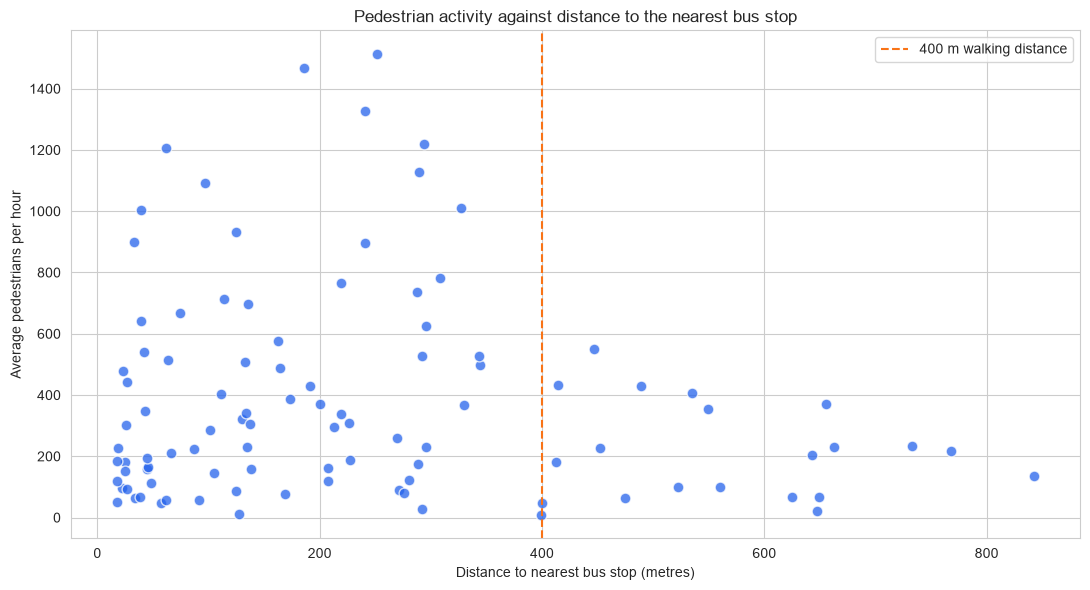

In [16]:
plt.figure(figsize=(11, 6))
plt.scatter(
    nearest["distance_to_nearest_stop_m"],
    nearest["avg_hourly_count"],
    s=60, alpha=0.75, color=BLUE, edgecolor="white",
)
plt.axvline(WALKING_DISTANCE_M, color=ORANGE, linestyle="--",
            label=f"{WALKING_DISTANCE_M} m walking distance")
plt.title("Pedestrian activity against distance to the nearest bus stop")
plt.xlabel("Distance to nearest bus stop (metres)")
plt.ylabel("Average pedestrians per hour")
plt.legend()
plt.tight_layout()
plt.show()

<div class="usecase-body">
<b>What this shows:</b> one point per sensor, with distance to the nearest bus stop across the bottom and average foot traffic up the side. The dashed line marks the 400 m walking threshold.
</div>

<div class="usecase-body">
<b>Why it matters:</b> the points to watch are high on the chart and to the right of the dashed line. Those are locations with heavy foot traffic and no bus stop within a comfortable walk, which is exactly the gap the scenario set out to find.
</div>

<div class="usecase-body">Finally we list those locations explicitly, so the finding is actionable rather than just visible on a chart.</div>

In [17]:
# Busy locations that are poorly served: above median foot traffic,
# but no bus stop within the walking threshold.
median_activity = nearest["avg_hourly_count"].median()

gaps = nearest[
    (nearest["avg_hourly_count"] > median_activity)
    & (nearest["distance_to_nearest_stop_m"] > WALKING_DISTANCE_M)
].sort_values("avg_hourly_count", ascending=False)

print(f"{len(gaps)} busy sensors sit more than {WALKING_DISTANCE_M} m from a bus stop.\n")

gaps[["sensor_name", "avg_hourly_count", "distance_to_nearest_stop_m", "stops_within_400m"]] \
    .round(1).head(10)

6 busy sensors sit more than 400 m from a bus stop.



,sensor_name,avg_hourly_count,distance_to_nearest_stop_m,stops_within_400m
60,LtB210_T,549.4,446.7,0
12,Bou231_T,432.3,414.6,0
57,Lon189_T,428.6,489.1,0
19,Bourke155_T,406.6,534.5,0
22,Col15_T,370.8,655.6,0
59,LtB170_T,353.1,548.9,0


<div class="usecase-body">
<b>What this shows:</b> the busiest pedestrian locations that have no bus stop within a five minute walk, ranked by foot traffic.
</div>

<div class="usecase-body">
<b>Why it matters:</b> this is the practical output of the notebook. Each row names a specific location where many people walk but bus access is weak, which is the evidence a planner needs when arguing for a new stop. An empty table is equally informative: it would mean every busy location is already well served.
</div>

<div id="section-6" class="usecase-section-heading"><b>6. Mapping the results</b></div>

<div class="usecase-body">
Maps make the pattern easy to read, but they have to be built carefully. Adding one marker per pedestrian reading would place hundreds of thousands of objects on a single map and freeze the browser. We map the summarised sensors instead, which is a few hundred objects at most.
</div>

<div id="sub-6-1" class="usecase-sub-section-heading"><b>6.1. Bus stops and pedestrian activity together</b></div>

<div class="usecase-body">Green circles are bus stops. Purple circles are sensors, sized by how busy they are.</div>

In [18]:
# Centre the map on the average sensor position.
map_centre = [sensors_geo["Latitude"].mean(), sensors_geo["Longitude"].mean()]
melbourne_map = folium.Map(location=map_centre, zoom_start=14, tiles="cartodbpositron")

# Bus stops: one small circle each (a few hundred, so this is safe).
stops_layer = folium.FeatureGroup(name="Bus stops")
for row in bus_stops_geo.itertuples():
    folium.CircleMarker(
        location=[row.Latitude, row.Longitude],
        radius=3, color=GREEN, fill=True, fill_opacity=0.85,
        popup=f"Bus stop: {row.descriptio}",
    ).add_to(stops_layer)
stops_layer.add_to(melbourne_map)

# Sensors: circle size scaled to average hourly count.
busiest = nearest["avg_hourly_count"].max()
sensors_layer = folium.FeatureGroup(name="Pedestrian sensors")
for row in nearest.to_crs(CRS_DEGREES).itertuples():
    folium.CircleMarker(
        location=[row.Latitude, row.Longitude],
        radius=4 + 16 * (row.avg_hourly_count / busiest),   # scaled, so the map stays readable
        color=PURPLE, fill=True, fill_opacity=0.55,
        popup=(f"{row.sensor_name}<br>"
               f"Average per hour: {row.avg_hourly_count:.0f}<br>"
               f"Nearest bus stop: {row.distance_to_nearest_stop_m:.0f} m"),
    ).add_to(sensors_layer)
sensors_layer.add_to(melbourne_map)

folium.LayerControl().add_to(melbourne_map)
melbourne_map

<div class="usecase-body">
<b>What this shows:</b> every bus stop and every pedestrian sensor on one interactive map, with sensor circles sized by average foot traffic. Clicking a circle gives its details, and the layer control switches each set on or off.
</div>

<div class="usecase-body">
<b>Why it matters:</b> it turns the numbers into geography. Large purple circles with few green circles around them are the access gaps identified in section 5, now visible in their actual street context.
</div>

<div id="sub-6-2" class="usecase-sub-section-heading"><b>6.2. Heat map of pedestrian activity</b></div>

<div class="usecase-body">A heat map shows where foot traffic concentrates, without drawing a separate marker for every reading.</div>

In [19]:
heat_map = folium.Map(location=map_centre, zoom_start=14, tiles="cartodbpositron")

# Each entry is [latitude, longitude, weight]; the weight is average foot traffic.
heat_points = nearest.to_crs(CRS_DEGREES)[
    ["Latitude", "Longitude", "avg_hourly_count"]
].values.tolist()

HeatMap(heat_points, radius=22, blur=16, min_opacity=0.35).add_to(heat_map)

# Bus stops on top for reference.
for row in bus_stops_geo.itertuples():
    folium.CircleMarker(
        location=[row.Latitude, row.Longitude],
        radius=2, color=GREEN, fill=True, fill_opacity=0.9,
    ).add_to(heat_map)

heat_map

<div class="usecase-body">
<b>What this shows:</b> the intensity of pedestrian activity across the city centre, with bus stops marked in green on top. Warmer areas are busier.
</div>

<div class="usecase-body">
<b>Why it matters:</b> the heat map answers the scenario at a glance. Where warm areas contain plenty of green dots, bus provision matches demand. Warm areas with few green dots are the places worth investigating, and they should match the sensors listed in section 5.
</div>

<div id="conclusion" class="usecase-unnumbered-heading"><b>Conclusion</b></div>

**What we achieved in this analysis**

We joined 309 bus stops to 100 pedestrian sensor locations using two years of hourly counts, roughly 1.6 million readings from August 2024 to August 2026. For every location we measured the distance to its nearest bus stop, counted the stops within a five minute walk, and tested both against how busy that location is.

**What we learned from this analysis**

<div class="usecase-body">
The analysis found that Melbourne's busiest pedestrian locations are generally well served by nearby bus stops. However, this does not necessarily mean the stops were located based on pedestrian activity, and six high-pedestrian locations were identified as exceptions where bus access is limited.
</div>

<div class="usecase-list">

- **Coverage across the city centre is good.** Half of all locations have a bus stop within 189 m and the closest is just 17 m away. 81 of the 100 locations have at least one stop inside a five minute walk, and a typical one has five to seven. The best served has 24.
- **Stop placement has nothing to do with foot traffic.** Both correlations came out at essentially zero: 0.02 against distance to the nearest stop, and -0.02 against the number of stops nearby. Busy locations are neither better nor worse served than quiet ones. Coverage is good because stops are dense everywhere in the centre, not because they follow pedestrian demand. This is association only, since busy streets attract both pedestrians and bus stops.
- **Six busy locations are poorly served.** These have above-average foot traffic and no bus stop within a five minute walk:
    - LtB210_T &mdash; 549 pedestrians per hour, nearest stop 447 m
    - Bou231_T &mdash; 432 per hour, 415 m
    - Lon189_T &mdash; 429 per hour, 489 m
    - Bourke155_T &mdash; 407 per hour, 535 m
    - Col15_T &mdash; 371 per hour, 656 m
    - LtB170_T &mdash; 353 per hour, 549 m
- **The gaps are not at the busiest places.** The busiest sensor of all records about 1,515 pedestrians an hour and has a stop close by. The underserved six sit in the middle of the range, at 350 to 550 an hour. The problem is not the headline locations that already get attention, but a set of steadily busy streets that are easy to overlook.

</div>

**What this does not tell us**

<div class="usecase-body">
Distances here are straight lines, so the real walk is longer wherever a river, rail line or blocked crossing gets in the way. The analysis covers buses only, and only the two years the API serves.
</div>

**Observations for further opportunities**

<div class="usecase-body">
The approach transfers to any two open datasets that both carry coordinates: summarise the busy one down to a row per place, convert both to a metre-based grid, and join on nearest neighbour. The same steps would answer "are childcare centres near parks" or "are charging stations near car parks".
</div>

<div class="usecase-list">

- Repeat the analysis by time of day, since access matters most at commuter peaks.
- Include tram and train stops to judge public transport access as a whole.
- Use street network walking distance rather than straight-line distance.
- Add service frequency, because a stop served once an hour is not the same as one served every five minutes.

</div>